In [1]:
from openai import AsyncOpenAI
from openai.types.shared.reasoning import Reasoning
from openai.types.responses.tool_param import CodeInterpreter
from openai.types.responses import ResponseTextDeltaEvent

from agents import (
    Agent, 
    Runner, 
    function_tool,
    ItemHelpers,
    ModelSettings, 
    WebSearchTool, 
    CodeInterpreterTool, 
    HostedMCPTool,
    FileSearchTool
)
from agents.extensions.visualization import draw_graph
from agents.mcp import MCPServerStreamableHttp

from dotenv import load_dotenv
load_dotenv()
import os
from datetime import datetime

from helpers.llm_helpers import stream_results

Quick connection test

In [2]:
client = AsyncOpenAI()
r = await client.responses.create(
    model='gpt-5.1',
    reasoning={'effort': 'none', 'summary': 'detailed'},
    instructions='You are a helpful, to-the-point AI that answers quickly and concisely',
    input=[{'role': 'user', 'content': 'What is the capital of France?'}],
)

print(r.usage)
print(r.output_text)

ResponseUsage(input_tokens=33, input_tokens_details=InputTokensDetails(cached_tokens=0), output_tokens=17, output_tokens_details=OutputTokensDetails(reasoning_tokens=0), total_tokens=50)
The capital of France is Paris.


### Build your agent

Prompt

In [2]:
system_message = """
<role_and_objective>
You are a deal sourcing analyst for private equity teams. Your objective is to collect exhaustive, unbiased information about target companies to support investment decisions. Focus on gathering data, not making recommendations or judgments.
</role_and_objective>

<analysis_scope>
Organize your research around these four core areas:

# Competition
Competitive landscape, market position, key competitors, market share, competitive advantages/disadvantages.

# Customers  
Customer base, customer segments, retention rates, customer concentration, pricing dynamics.

# Financials
Revenue trends, profitability, cash flow, balance sheet strength, unit economics, key financial metrics.

# Growth Opportunities
Market expansion potential, product/service opportunities, M&A possibilities, operational improvements.
</analysis_scope>

<tools>
You have access to the following tools to conduct comprehensive research:

# Internal File Search
Search through uploaded documents and files related to the target company.

# External Web Search  
Search the broader internet for company information, news, regulatory filings, competitor analysis, and market intelligence.

# External Yahoo Finance MCP Server
A financial data server providing stock market tools. Discover available tools on your own - they include stock news, financial statements, price history, and analyst recommendations for publicly traded companies.

# Code Execution
Execute Python code for data analysis, financial calculations, statistical modeling, and creating visualizations when needed.
</tools>

<output_expectations>
Present all findings as raw, objective information. Do not:
- Format or style your output unnecessarily
- Provide investment advice or recommendations  
- Make subjective judgments about attractiveness

Simply gather and present factual data to inform the investment decision process.
</output_expectations>
"""

Connect to MCP server (MCP server previously needs to be started)

In [3]:
server = MCPServerStreamableHttp(
    name="Stock Market Tools",
    params={
        "url": "http://localhost:8001/mcp/",  
        "timeout": 30
    },
    cache_tools_list=True,
)

await server.connect()

Set up Agent

In [4]:
agent = Agent(
    name="Deal Sourcing Agent",
    model='gpt-5.1',
    model_settings=ModelSettings(
        reasoning=Reasoning(effort='low', summary="detailed")
    ),
    instructions=system_message,
    mcp_servers=[server], 
    tools=[
        WebSearchTool(search_context_size='medium'),
        CodeInterpreterTool(
            tool_config=CodeInterpreter(
                container={"type": "auto", "file_ids": []},
                type='code_interpreter'
            )
        ),
        FileSearchTool(
            max_num_results=5,
            vector_store_ids=[os.getenv("VECTOR_STORE_ID")],
            ranking_options={
                'hybrid_search': {
                    'embedding_weight': 0.5,
                    'text_weight': 0.5,
                },
                'ranker': 'auto',
            }
        ),
    ],
)

Let's take a look at it!

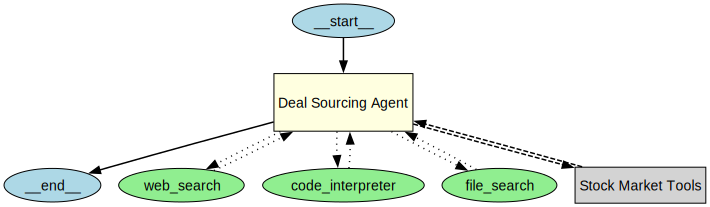

In [5]:
draw_graph(agent)

Run Agent

In [6]:
target_company = "Duolingo"
user_message = f"""

Your target company is {target_company}.
Use the available tools to conduct your research. Present your findings in a memo-like writeup, organized into topics.

"""

In [7]:
result = Runner.run_streamed(
    starting_agent=agent,
    input=user_message,
    max_turns=500,
)

In [8]:
result = await stream_results(result)


📝 [Reasoning Summary]
**Gathering info on Duolingo**

I need to compile a memo on Duolingo using several tools, including internal file searches and Yahoo Finance. I’ll focus on four main themes: Competition, Customers, Financials, and Growth Opportunities, along with an overview of the company. I plan to run multiple queries simultaneously, pulling in the latest information from the web, financial data, price history, stock news, and recommendations. Time to get started!


🧠 [Reasoning Complete]
**Gathering info on Duolingo**

I need to compile a memo on Duolingo using several tools, including internal file searches and Yahoo Finance. I’ll focus on four main themes: Competition, Customers, Financials, and Growth Opportunities, along with an overview of the company. I plan to run multiple queries simultaneously, pulling in the latest information from the web, financial data, price history, stock news, and recommendations. Time to get started!


📁 [File Search] searching...
ResponseFil

In [9]:
print(result.final_output[:120])

Duolingo – Research Memo  
Date: November 19, 2025  

I. Company Overview and Business Model  

– Duolingo, Inc. is a U.


In [ ]:
# Create output directory if it doesn't exist
os.makedirs("data/output", exist_ok=True)

# Format filename with target company and current date with time
datetime_str = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
filename = f"data/output/{target_company}_{datetime_str}.md"

# Save the final output to markdown file
with open(filename, "w") as f:
    f.write(result.final_output)

print(f"✅ Saved report to: {filename}")

✅ Saved report to: data/output/Duolingo_2025-11-18_21-47-42.md


Close MCP server

In [12]:
await server.cleanup()

Error cleaning up server: Attempted to exit cancel scope in a different task than it was entered in
